# 야간 밝기 클러스터 × 고령화율 통합 분석

`3_kmeans_clustering.ipynb` 결과와 `1_aging_rate.ipynb`의 2023년 고령화율을 KOSIS 시군구 코드 기준으로 붙여서 상관관계를 분석.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('준비 완료')

준비 완료


In [2]:
df_cluster = pd.read_csv('kmeans_sgg_cluster.csv', encoding='utf-8-sig', dtype={'SGG_CODE': str})
df_aging = pd.read_csv('aging_rate_2019_2023.csv', encoding='utf-8-sig', dtype={'SGG_CODE': str})

print('=== 클러스터 데이터 ===')
print(df_cluster.shape)
print(df_cluster.head(3))

print('\n=== 고령화율 데이터 ===')
print(df_aging.shape)
print(df_aging.head(3))

=== 클러스터 데이터 ===
(248, 5)
  SGG_CODE SGG_NM  nightlight_avg  cluster cluster_name
0    11010    종로구       61.153505        2          고광도
1    11020     중구      116.211756        2          고광도
2    11030    용산구       63.014543        2          고광도

=== 고령화율 데이터 ===
(1305, 6)
  SGG_CODE SGG_NM      전체인구  year  65세이상인구   고령화율
0    11010    종로구  146603.0  2019  24829.5  16.94
1    11010    종로구  144865.5  2020  25595.0  17.67
2    11010    종로구  142767.0  2021  26336.0  18.45


In [3]:
# KOSIS 5자리 코드로 통일
df_cluster['SGG_CODE'] = df_cluster['SGG_CODE'].astype(str).str.zfill(5)
df_aging['SGG_CODE'] = df_aging['SGG_CODE'].astype(str).str.zfill(5)

print('클러스터 코드 예시:', df_cluster['SGG_CODE'].head(3).tolist())
print('고령화율 코드 예시:', df_aging['SGG_CODE'].head(3).tolist())

클러스터 코드 예시: ['11010', '11020', '11030']
고령화율 코드 예시: ['11010', '11010', '11010']


In [4]:
# 2023년 고령화율
df_aging_2023 = df_aging[df_aging['year'] == 2023][['SGG_CODE', 'SGG_NM', '고령화율']].copy()

# KOSIS 코드 기준 merge
df = pd.merge(
    df_cluster,
    df_aging_2023,
    on='SGG_CODE',
    how='inner',
    suffixes=('_cluster', '_aging'),
)

# 클러스터 CSV에 이미 SGG_NM이 있으면 aging 쪽 이름 사용
if 'SGG_NM_cluster' in df.columns:
    df['SGG_NM'] = df['SGG_NM_aging'].fillna(df['SGG_NM_cluster'])
    df.drop(columns=['SGG_NM_cluster', 'SGG_NM_aging'], inplace=True)

print(f'합쳐진 시군구 수: {len(df)}')
print(df[['SGG_CODE', 'SGG_NM', 'nightlight_avg', 'cluster_name', '고령화율']].head(10))

합쳐진 시군구 수: 248
  SGG_CODE SGG_NM  nightlight_avg cluster_name   고령화율
0    11010    종로구       61.153505          고광도  19.97
1    11020     중구      116.211756          고광도  20.73
2    11030    용산구       63.014543          고광도  17.90
3    11040    성동구       68.623413          고광도  17.32
4    11050    광진구       60.120014          중광도  16.37
5    11060   동대문구       72.366420          고광도  19.36
6    11070    중랑구       60.106917          고광도  20.04
7    11080    성북구       63.799767          고광도  18.40
8    11090    강북구       39.403750          중광도  23.22
9    11100    도봉구       37.821600          중광도  22.22


              평균 고령화율    중앙값  시군구 수
cluster_name                       
고광도             19.15  18.40     28
저광도             26.95  27.23    161
중광도             17.86  17.23     59


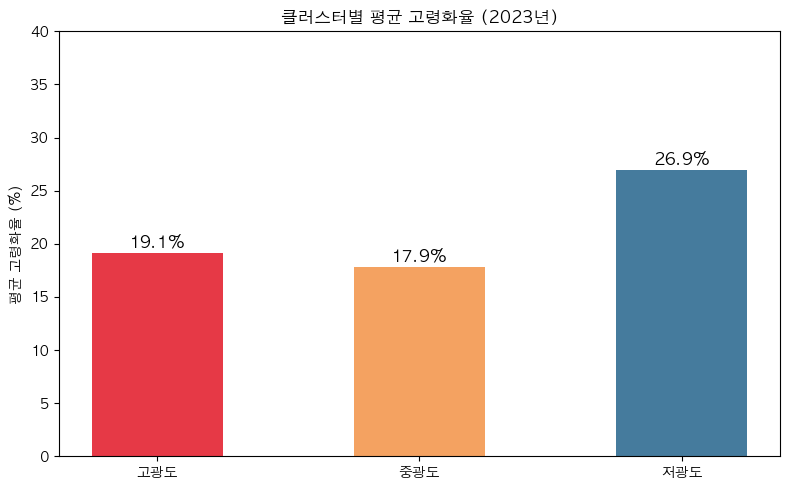

In [5]:
summary = df.groupby('cluster_name')['고령화율'].agg(['mean', 'median', 'count']).round(2)
summary.columns = ['평균 고령화율', '중앙값', '시군구 수']
print(summary)

order = ['고광도', '중광도', '저광도']
means = [df[df['cluster_name'] == c]['고령화율'].mean() for c in order]

plt.figure(figsize=(8, 5))
bars = plt.bar(order, means, color=['#e63946', '#f4a261', '#457b9d'], width=0.5)
plt.ylabel('평균 고령화율 (%)')
plt.title('클러스터별 평균 고령화율 (2023년)')
plt.ylim(0, 40)

for bar, val in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

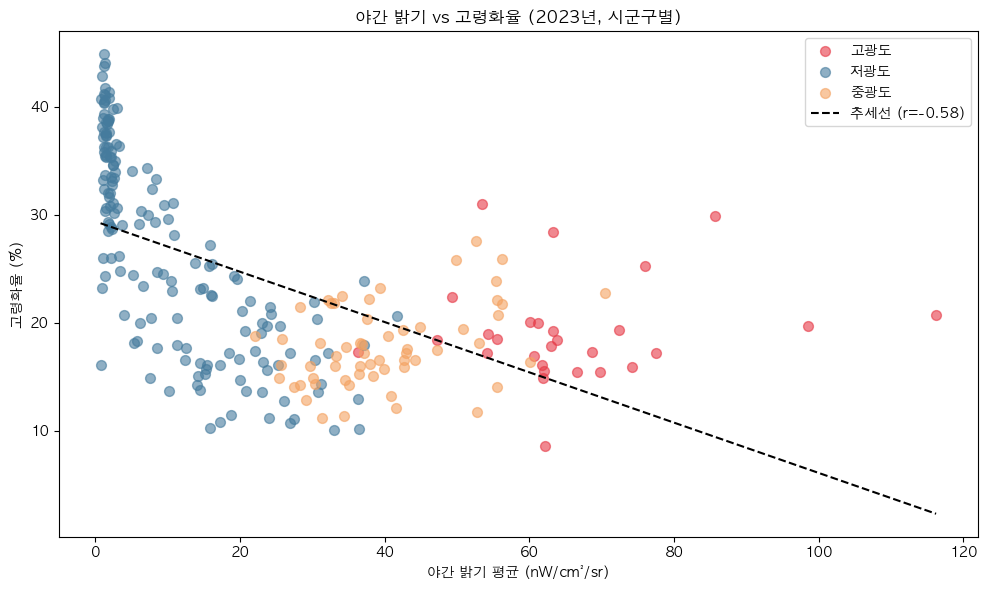


상관계수 r = -0.578
p-value = 0.0000
→ 통계적으로 유의미한 상관관계!


In [6]:
color_map = {'고광도': '#e63946', '중광도': '#f4a261', '저광도': '#457b9d'}

plt.figure(figsize=(10, 6))

for name, group in df.groupby('cluster_name'):
    plt.scatter(group['nightlight_avg'], group['고령화율'],
                label=name, color=color_map[name], alpha=0.6, s=50)

slope, intercept, r, p, _ = stats.linregress(df['nightlight_avg'], df['고령화율'])
x_line = np.linspace(df['nightlight_avg'].min(), df['nightlight_avg'].max(), 100)
plt.plot(x_line, slope * x_line + intercept, 'k--', linewidth=1.5, label=f'추세선 (r={r:.2f})')

plt.xlabel('야간 밝기 평균 (nW/cm²/sr)')
plt.ylabel('고령화율 (%)')
plt.title('야간 밝기 vs 고령화율 (2023년, 시군구별)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\n상관계수 r = {r:.3f}')
print(f'p-value = {p:.4f}')
if p < 0.05:
    print('→ 통계적으로 유의미한 상관관계!')

In [7]:
df.to_csv('cluster_aging_merged.csv', index=False, encoding='utf-8-sig')
print('저장 완료: cluster_aging_merged.csv')
print(df[['SGG_CODE', 'SGG_NM', 'nightlight_avg', 'cluster_name', '고령화율']].head())

저장 완료: cluster_aging_merged.csv
  SGG_CODE SGG_NM  nightlight_avg cluster_name   고령화율
0    11010    종로구       61.153505          고광도  19.97
1    11020     중구      116.211756          고광도  20.73
2    11030    용산구       63.014543          고광도  17.90
3    11040    성동구       68.623413          고광도  17.32
4    11050    광진구       60.120014          중광도  16.37
